In [25]:
import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Filter For Indian Data Analyst Roles

In [26]:
df_DA_In=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='India')].copy()
df_DA_us=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

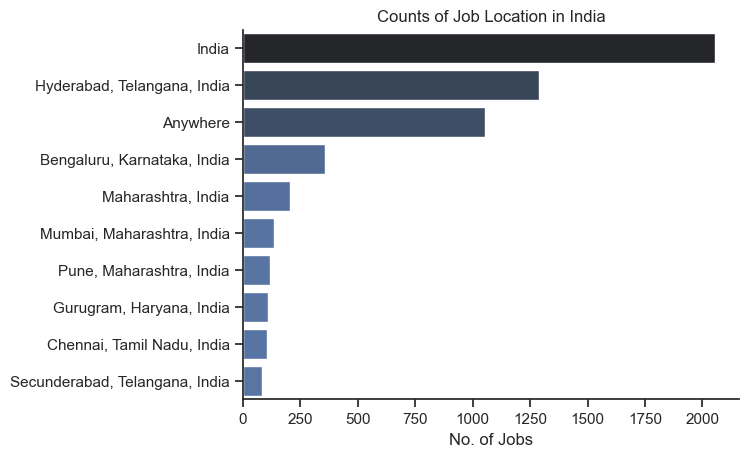

In [27]:
df_plot=df_DA_In['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title("Counts of Job Location in India")
plt.xlabel('No. of Jobs')
plt.ylabel('')
plt.show()

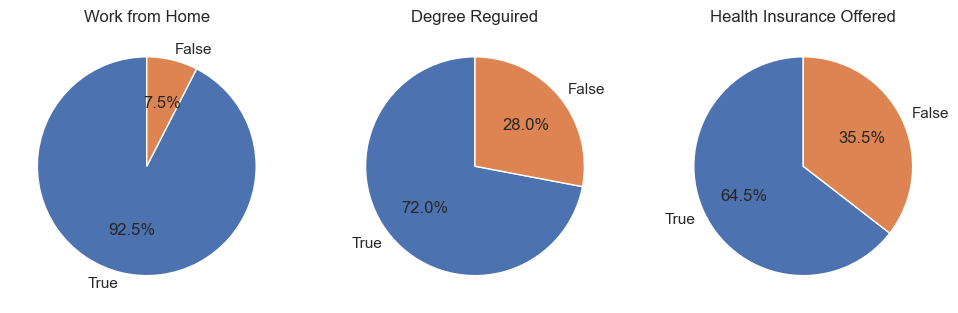

<Figure size 640x480 with 0 Axes>

In [28]:
dict_col = {
    "job_work_from_home": 'Work from Home',
    "job_no_degree_mention":'Degree Reguired',
    "job_health_insurance":'Health Insurance Offered'
}
fig, ax=plt.subplots(1,3)
fig.set_size_inches((12,5))

for i, (column, title) in enumerate(dict_col.items()):
    ax[i].pie(df_DA_us[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=['True','False'])
    ax[i].set_title(title)

plt.show()
plt.tight_layout()

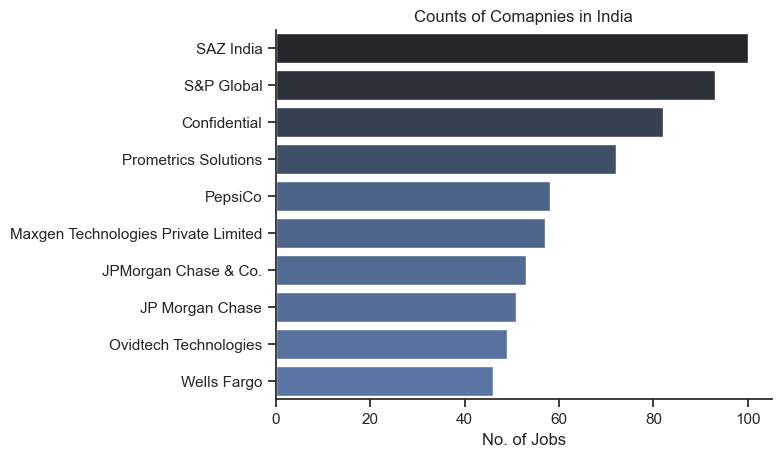

In [29]:
df_plot=df_DA_In['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title("Counts of Comapnies in India")
plt.xlabel('No. of Jobs')
plt.ylabel('')
plt.show()